# Task 1: Persuasion Detection — Multi-Label Classification for SemEval-2023 Task 3

**Paper:** *Towards Detecting Persuasion on Social Media: From Model Development to Insights on Persuasion Strategies*  
**Authors:** Meguellati et al. (2025)

This notebook implements the PPAsy-XLNet model for multi-label persuasion technique detection on the SemEval-2023 Task 3 Subtask 3 dataset. The approach uses XLNet-base with an asymmetric binary cross-entropy loss function to handle class imbalance across 23 persuasion technique labels.

**Expected file structure:**
```
persuasion_project/
├── data/semeval/
│   ├── spacy_cleaned_train.csv
│   ├── spacy_cleaned_dev.csv
│   ├── spacy_cleaned_test.csv
│   └── fr_cleaned_train.csv
└── ...
```

In [1]:
# Install all dependencies
# ⚠️  After running this cell → Runtime → Restart session → then run from Cell 2 downward
!pip install -q tf-keras
!pip install -q transformers==4.37.2 sentencepiece
!pip install -q scikit-learn pandas numpy matplotlib seaborn

> **⚠️ Restart required:** After the cell above finishes, go to **Runtime → Restart session**, then run all remaining cells in order.

In [1]:
# ⚠️ Run this FIRST after restarting the session — must execute before any TensorFlow import
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/persuasion_project"
DATA_SEMEVAL = os.path.join(PROJECT_ROOT, "data", "semeval")
DATA_ADS     = os.path.join(PROJECT_ROOT, "data", "ads")
MODELS_DIR   = os.path.join(PROJECT_ROOT, "models")

print(f"Project root: {os.path.abspath(PROJECT_ROOT)}")
assert os.path.isdir(os.path.join(PROJECT_ROOT, "data")), (
    f"Cannot find 'data/' in {os.path.abspath(PROJECT_ROOT)}. Update PROJECT_ROOT above."
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/persuasion_project


## Setup & Imports

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, f1_score
from transformers import XLNetTokenizer, TFXLNetModel
import transformers.modeling_tf_utils as modeling_tf_utils
import matplotlib.pyplot as plt
import seaborn as sns

# Patch backend helpers expected by transformers when running with newer Keras builds.
def _compat_int_shape(x):
    return tuple(x.shape.as_list()) if hasattr(x.shape, "as_list") else tuple(x.shape)

def _compat_batch_set_value(weight_value_tuples):
    for variable, value in weight_value_tuples:
        variable.assign(value)

if not hasattr(modeling_tf_utils.K, "int_shape"):
    modeling_tf_utils.K.int_shape = _compat_int_shape

if not hasattr(modeling_tf_utils.K, "batch_set_value"):
    modeling_tf_utils.K.batch_set_value = _compat_batch_set_value

## Data Loading

In [4]:
cleaned_train_path = os.path.join(DATA_SEMEVAL, "fr_cleaned_train.csv")
cleaned_dev_path   = os.path.join(DATA_SEMEVAL, "spacy_cleaned_dev.csv")
cleaned_test_path  = os.path.join(DATA_SEMEVAL, "spacy_cleaned_test.csv")

train_df = pd.read_csv(cleaned_train_path, index_col=0)
dev_df   = pd.read_csv(cleaned_dev_path,   index_col=0)
test_df  = pd.read_csv(cleaned_test_path,  index_col=0)

train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
dev_df   = dev_df.sample(frac=1,   random_state=42).reset_index(drop=True)
test_df  = test_df.sample(frac=1,  random_state=42).reset_index(drop=True)

print(f"Train: {len(train_df)} samples")
print(f"Dev:   {len(dev_df)} samples")
print(f"Test:  {len(test_df)} samples")
print(train_df.head())

Train: 2130 samples
Dev:   1120 samples
Test:  910 samples
   line                                               text  \
0    33  if they do this , they will trigger a monstrou...   
1    25  with the conflict in ukraine , it be now the i...   
2     7  they never sleep , as their first reaction thi...   
3    36  alignment of the charge weigh on the full sala...   
4     9  macron also warn that russia should not be " h...   

                                              labels  
0  Appeal_to_Fear-Prejudice,Consequential_Oversim...  
1                                    Loaded_Language  
2  Appeal_to_Fear-Prejudice,Appeal_to_Hypocrisy,A...  
3                                    Loaded_Language  
4                                    Loaded_Language  


## Preprocessing

In [5]:
# Parameters
max_words = 10000
max_len = 128

# Keras tokenizer for sequence padding
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(train_df['text'])

train_seq = tokenizer.texts_to_sequences(train_df['text'])
dev_seq = tokenizer.texts_to_sequences(dev_df['text'])
test_seq = tokenizer.texts_to_sequences(test_df['text'])

train_seq_padded = pad_sequences(train_seq, maxlen=max_len)
dev_seq_padded = pad_sequences(dev_seq, maxlen=max_len)
test_seq_padded = pad_sequences(test_seq, maxlen=max_len)

# Multi-label binarization
mlb = MultiLabelBinarizer()
train_labels = mlb.fit_transform([set(label.split(',')) for label in train_df['labels']])
dev_labels = mlb.transform([set(label.split(',')) for label in dev_df['labels']])

num_classes = len(mlb.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {list(mlb.classes_)}")

Number of classes: 23
Classes: ['Appeal_to_Authority', 'Appeal_to_Fear-Prejudice', 'Appeal_to_Hypocrisy', 'Appeal_to_Popularity', 'Appeal_to_Time', 'Appeal_to_Values', 'Causal_Oversimplification', 'Consequential_Oversimplification', 'Conversation_Killer', 'Doubt', 'Exaggeration-Minimisation', 'False_Dilemma-No_Choice', 'Flag_Waving', 'Guilt_by_Association', 'Loaded_Language', 'Name_Calling-Labeling', 'Obfuscation-Vagueness-Confusion', 'Questioning_the_Reputation', 'Red_Herring', 'Repetition', 'Slogans', 'Straw_Man', 'Whataboutism']


## XLNet Tokenizer

In [6]:
# Initialize XLNet-base tokenizer
xlnet_tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased')

# Tokenize for XLNet
train_xlnet = xlnet_tokenizer(train_df['text'].tolist(), padding='max_length', truncation=True,
                               max_length=max_len, return_tensors="tf")
dev_xlnet = xlnet_tokenizer(dev_df['text'].tolist(), padding='max_length', truncation=True,
                             max_length=max_len, return_tensors="tf")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

## Loss Function

The asymmetric binary cross-entropy loss addresses class imbalance by weighting positive and negative samples differently via a parameter β. When β > 0.5, the loss penalises false negatives more heavily, encouraging the model to detect minority-class persuasion techniques.

In [7]:
def asymmetric_binary_crossentropy(beta):
    """Asymmetric BCE loss: weights positive samples by beta and negatives by (1-beta)."""
    def loss(y_true, y_pred):
        y_true = K.cast(y_true, 'float32')
        y_pred = K.cast(y_pred, 'float32')
        bce = K.binary_crossentropy(y_true, y_pred)
        weight_vector = y_true * beta + (1 - y_true) * (1 - beta)
        weighted_bce = weight_vector * bce
        return K.mean(weighted_bce)
    return loss

# Hyperparameters (tuned via Optuna)
beta = 0.7

## Model Architecture

XLNet-base (110M parameters) with mean pooling over token embeddings, followed by dropout and a sigmoid output layer for multi-label classification.

In [8]:
# XLNet input
input_xlnet = Input(shape=(max_len,), dtype='int32', name="xlnet_input")

# XLNet embedding layer
xlnet_model = TFXLNetModel.from_pretrained('xlnet-base-cased')
xlnet_embedding = xlnet_model(input_xlnet)[0]

# Mean pooling over sequence length
mean_pooling = Lambda(lambda x: tf.reduce_mean(x, axis=1))(xlnet_embedding)

# Classification head
dropout = Dropout(0.1)(mean_pooling)
final_output = Dense(num_classes, activation='sigmoid')(dropout)

# Compile
xlnet_final_model = Model(inputs=input_xlnet, outputs=final_output)
xlnet_final_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=asymmetric_binary_crossentropy(beta),
    metrics=['accuracy']
)

xlnet_final_model.summary()

tf_model.h5:   0%|          | 0.00/565M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(
Some layers from the model checkpoint at xlnet-base-cased were not used when initializing TFXLNetModel: ['lm_loss']
- This IS expected if you are initializing TFXLNetModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFXLNetModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFXLNe

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 xlnet_input (InputLayer)    [(None, 128)]             0         
                                                                 
 tfxl_net_model (TFXLNetMod  TFXLNetModelOutput(last   116718336 
 el)                         _hidden_state=(None, 12             
                             8, 768),                            
                              mems=((128, None, 768)             
                             , (128, None, 768),                 
                              (128, None, 768),                  
                              (128, None, 768),                  
                              (128, None, 768),                  
                              (128, None, 768),                  
                              (128, None, 768),                  
                              (128, None, 768),              

## Training

In [9]:
history = xlnet_final_model.fit(
    train_xlnet['input_ids'], train_labels,
    epochs=5,
    validation_data=(dev_xlnet['input_ids'], dev_labels),
    verbose=1
)

Epoch 1/5


67/67 [==============================] - 67s 299ms/step - loss: 0.1786 - accuracy: 0.1756 - val_loss: 0.1127 - val_accuracy: 0.2929
Epoch 2/5
67/67 [==============================] - 16s 236ms/step - loss: 0.1539 - accuracy: 0.1883 - val_loss: 0.1118 - val_accuracy: 0.2929
Epoch 3/5
67/67 [==============================] - 14s 208ms/step - loss: 0.1531 - accuracy: 0.1906 - val_loss: 0.1107 - val_accuracy: 0.2929
Epoch 4/5
67/67 [==============================] - 13s 196ms/step - loss: 0.1486 - accuracy: 0.1878 - val_loss: 0.1179 - val_accuracy: 0.2929
Epoch 5/5
67/67 [==============================] - 12s 176ms/step - loss: 0.1444 - accuracy: 0.1854 - val_loss: 0.1077 - val_accuracy: 0.2929


## Evaluation & Threshold Calibration

In [10]:
def calculate_scores(y_true, y_pred, threshold=0.5):
    """Calculate accuracy, F1-micro, and F1-macro at a given threshold."""
    y_pred_bool = (y_pred > threshold).astype(int)
    acc = accuracy_score(y_true, y_pred_bool)
    f1_micro = f1_score(y_true, y_pred_bool, average='micro')
    f1_macro = f1_score(y_true, y_pred_bool, average='macro')
    return acc, f1_micro, f1_macro

# Generate predictions
train_pred = xlnet_final_model.predict(train_xlnet['input_ids'])
dev_pred = xlnet_final_model.predict(dev_xlnet['input_ids'])

# Evaluate at default threshold (0.5)
train_acc, train_f1_micro, train_f1_macro = calculate_scores(train_labels, train_pred)
dev_acc, dev_f1_micro, dev_f1_macro = calculate_scores(dev_labels, dev_pred)

print('In-sample Acc:        ', train_acc)
print('Dev Acc:              ', dev_acc)
print('In-sample F1 (Micro): ', train_f1_micro)
print('Dev F1 (Micro):       ', dev_f1_micro)
print('In-sample F1 (Macro): ', train_f1_macro)
print('Dev F1 (Macro):       ', dev_f1_macro)

35/35 [==============================] - 1s 36ms/step
In-sample Acc:         0.11549295774647887
Dev Acc:               0.22232142857142856
In-sample F1 (Micro):  0.4659153080205712
Dev F1 (Micro):        0.3684941013185288
In-sample F1 (Macro):  0.17383317129855613
Dev F1 (Macro):        0.044403303095558976


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Threshold Sweep on Dev Set

In [11]:
thresholds = np.arange(0.25, 0.8, 0.05)

for threshold in thresholds:
    dev_acc, dev_f1_micro, dev_f1_macro = calculate_scores(dev_labels, dev_pred, threshold)
    print(f'Threshold: {threshold:.2f}  |  Dev Acc: {dev_acc:.4f}  |  '
          f'F1-Micro: {dev_f1_micro:.4f}  |  F1-Macro: {dev_f1_macro:.4f}')

Threshold: 0.25  |  Dev Acc: 0.0277  |  F1-Micro: 0.3430  |  F1-Macro: 0.1079
Threshold: 0.30  |  Dev Acc: 0.0813  |  F1-Micro: 0.3606  |  F1-Macro: 0.0997
Threshold: 0.35  |  Dev Acc: 0.1509  |  F1-Micro: 0.3681  |  F1-Macro: 0.0881
Threshold: 0.40  |  Dev Acc: 0.1804  |  F1-Micro: 0.3715  |  F1-Macro: 0.0739
Threshold: 0.45  |  Dev Acc: 0.2143  |  F1-Micro: 0.3720  |  F1-Macro: 0.0557
Threshold: 0.50  |  Dev Acc: 0.2223  |  F1-Micro: 0.3685  |  F1-Macro: 0.0444
Threshold: 0.55  |  Dev Acc: 0.2161  |  F1-Micro: 0.3638  |  F1-Macro: 0.0397
Threshold: 0.60  |  Dev Acc: 0.1938  |  F1-Micro: 0.3544  |  F1-Macro: 0.0381
Threshold: 0.65  |  Dev Acc: 0.1509  |  F1-Micro: 0.3170  |  F1-Macro: 0.0331
Threshold: 0.70  |  Dev Acc: 0.1143  |  F1-Micro: 0.2766  |  F1-Macro: 0.0288
Threshold: 0.75  |  Dev Acc: 0.0759  |  F1-Micro: 0.2136  |  F1-Macro: 0.0232


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/di

### Test Set Predictions

In [12]:
# Load and tokenize test set
test_df = pd.read_csv(cleaned_test_path, index_col=0)
test_df.reset_index(inplace=True)

test_xlnet = xlnet_tokenizer(test_df['text'].tolist(), padding='max_length', truncation=True,
                              max_length=max_len, return_tensors="tf")

# Generate predictions
test_pred = xlnet_final_model.predict(test_xlnet['input_ids'])

# Apply default threshold (0.5)
test_pred_bool = (test_pred >= 0.5).astype(int)
test_pred_labels = mlb.inverse_transform(test_pred_bool)
test_pred_str = [','.join(labels) if labels else '' for labels in test_pred_labels]

# Create output DataFrame
output_df = pd.DataFrame({
    'id': test_df['id'],
    'line': test_df['line'],
    'labels': test_pred_str
})

print(f"Test predictions generated for {len(output_df)} samples.")
print(output_df.head(10))

29/29 [==============================] - 1s 36ms/step
Test predictions generated for 910 samples.
     id  line                                             labels
0  3121     1                                    Loaded_Language
1  3121     3                                    Loaded_Language
2  3121     5                                    Loaded_Language
3  3121     7  Loaded_Language,Name_Calling-Labeling,Question...
4  3121     9  Appeal_to_Fear-Prejudice,Exaggeration-Minimisa...
5  3121    11  Appeal_to_Fear-Prejudice,Exaggeration-Minimisa...
6  3121    13           Appeal_to_Fear-Prejudice,Loaded_Language
7  3121    15                                                   
8  3121    17                                                   
9  3121    19                                    Loaded_Language


## Benchmark Comparison

Comparison of PPAsy-XLNet against published models on the SemEval-2023 Task 3 English test set.

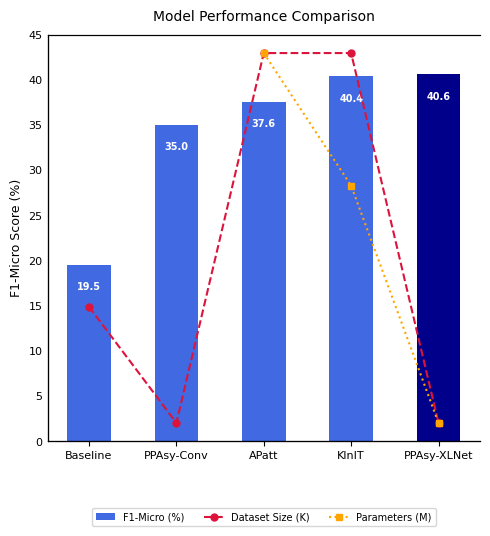

In [13]:
import matplotlib.pyplot as plt

# Performance data from Table 2 in the paper
methods = ['Baseline', 'PPAsy-Conv', 'APatt', 'KInIT', 'PPAsy-XLNet']
dataset_sizes = [469, 153, 1160, 1160, 153]       # in thousands
parameters = [np.nan, np.nan, 492, 355, 110]       # in millions
f1_micro = [19.51, 35.01, 37.56, 40.38, 40.62]

df_bench = pd.DataFrame({
    'Method': methods,
    'Dataset_Size': dataset_sizes,
    'Parameters': parameters,
    'F1_Micro': f1_micro
})

# --- Bar chart with dataset size & parameter overlays ---
fig, ax1 = plt.subplots(figsize=(5, 5.5))

bar_colors = ['royalblue'] * 4 + ['darkblue']
bars = ax1.bar(df_bench['Method'], df_bench['F1_Micro'], color=bar_colors, width=0.5)

ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 30))

ax2.plot(df_bench['Method'], df_bench['Dataset_Size'], color='crimson', linewidth=1.5,
         marker='o', markersize=5, label='Dataset Size (K)', linestyle='--')
ax3.plot(df_bench['Method'], df_bench['Parameters'], color='orange', linewidth=1.5,
         marker='s', markersize=5, label='Parameters (M)', linestyle=':')

ax2.set_yticks([]); ax3.set_yticks([])
ax2.spines['right'].set_visible(False); ax3.spines['right'].set_visible(False)

ax1.set_ylim(0, 45)
ax1.set_ylabel('F1-Micro Score (%)', fontsize=9)
ax1.tick_params(axis='y', labelsize=8, length=0)
ax1.tick_params(axis='x', labelsize=8, rotation=0)

for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h - 3, f'{h:.1f}',
             ha='center', va='bottom', fontsize=7, color='white', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend([bars[0]] + ax2.get_lines() + ax3.get_lines(),
           ['F1-Micro (%)'] + labels2 + labels3,
           loc='lower center', bbox_to_anchor=(0.5, -0.22), fontsize=7, ncol=3, frameon=True)

ax1.grid(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
plt.title('Model Performance Comparison', fontsize=10, pad=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3760/3882960443.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(df_bench['Method'], rotation=45, ha='right')


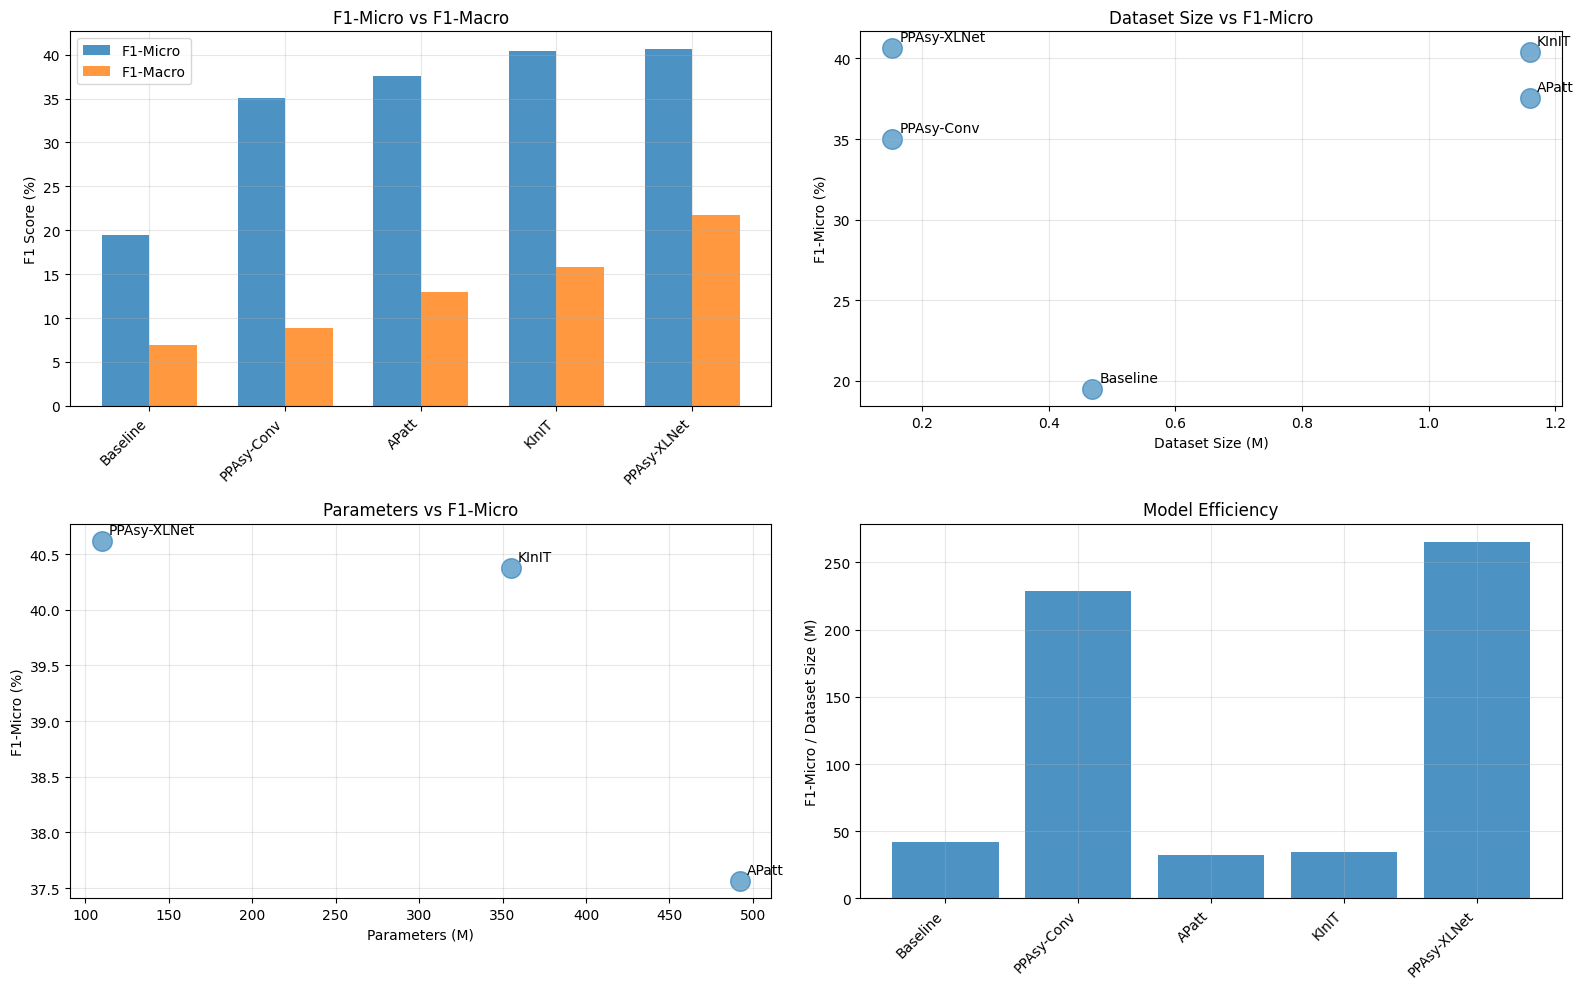

In [14]:
# --- Multi-panel analysis ---
import seaborn as sns

f1_macro = [6.93, 8.89, 12.92, 15.86, 21.78]
df_bench['F1_Macro'] = f1_macro

fig = plt.figure(figsize=(16, 10))

# 1. F1-Micro vs F1-Macro
ax1 = plt.subplot(221)
bar_width = 0.35
indices = np.arange(len(df_bench))
ax1.bar(indices - bar_width/2, df_bench['F1_Micro'], bar_width, label='F1-Micro', alpha=0.8)
ax1.bar(indices + bar_width/2, df_bench['F1_Macro'], bar_width, label='F1-Macro', alpha=0.8)
ax1.set_xticks(indices); ax1.set_xticklabels(df_bench['Method'], rotation=45, ha='right')
ax1.set_ylabel('F1 Score (%)'); ax1.set_title('F1-Micro vs F1-Macro'); ax1.legend(); ax1.grid(True, alpha=0.3)

# 2. Dataset Size vs F1-Micro
ax2 = plt.subplot(222)
sizes = df_bench['Dataset_Size'] / 1000
ax2.scatter(sizes, df_bench['F1_Micro'], s=200, alpha=0.6)
for i, m in enumerate(df_bench['Method']):
    ax2.annotate(m, (sizes.iloc[i], df_bench['F1_Micro'].iloc[i]), xytext=(5, 5), textcoords='offset points')
ax2.set_xlabel('Dataset Size (M)'); ax2.set_ylabel('F1-Micro (%)'); ax2.set_title('Dataset Size vs F1-Micro'); ax2.grid(True, alpha=0.3)

# 3. Parameters vs F1-Micro
ax3 = plt.subplot(223)
params_df = df_bench[df_bench['Parameters'].notna()]
ax3.scatter(params_df['Parameters'], params_df['F1_Micro'], s=200, alpha=0.6)
for _, row in params_df.iterrows():
    ax3.annotate(row['Method'], (row['Parameters'], row['F1_Micro']), xytext=(5, 5), textcoords='offset points')
ax3.set_xlabel('Parameters (M)'); ax3.set_ylabel('F1-Micro (%)'); ax3.set_title('Parameters vs F1-Micro'); ax3.grid(True, alpha=0.3)

# 4. Efficiency
ax4 = plt.subplot(224)
efficiency = df_bench['F1_Micro'] / (df_bench['Dataset_Size'] / 1000)
ax4.bar(df_bench['Method'], efficiency, alpha=0.8)
ax4.set_xticklabels(df_bench['Method'], rotation=45, ha='right')
ax4.set_ylabel('F1-Micro / Dataset Size (M)'); ax4.set_title('Model Efficiency'); ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
from google.colab import runtime
runtime.unassign()
